In [6]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def fetch_stock_data(tickers, start_date, end_date):
    """
    Fetches adjusted closing prices for the specified tickers and date range.

    Parameters:
    - tickers (list): List of stock ticker symbols.
    - start_date (str): Start date in 'YYYY-MM-DD' format.
    - end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
    - DataFrame: Adjusted closing prices with dates as index and tickers as columns.
    """
    data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
    return data

def calculate_correlations(data):
    """
    Calculates the correlation matrix for the given stock data.

    Parameters:
    - data (DataFrame): DataFrame containing stock prices.

    Returns:
    - DataFrame: Correlation matrix.
    """
    return data.corr()

def plot_heatmap(corr_matrix, title='Stock Correlation Heatmap'):
    """
    Plots a heatmap of the correlation matrix.

    Parameters:
    - corr_matrix (DataFrame): Correlation matrix.
    - title (str): Title of the heatmap.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


[                       0%                       ]

Fetching stock data...


[*********************100%***********************]  5 of 5 completed


Sample of fetched data:
Ticker                           COKE     LNF.TO         PEP         TGT  \
Date                                                                       
2024-01-02 00:00:00+00:00  912.800598  18.142437  167.544724  138.977005   
2024-01-03 00:00:00+00:00  902.100342  18.363688  167.583481  134.674622   
2024-01-04 00:00:00+00:00  894.289978  18.594557  166.149399  136.209106   
2024-01-05 00:00:00+00:00  885.620422  18.373306  163.697891  136.694717   
2024-01-08 00:00:00+00:00  892.971924  18.758089  163.862625  137.646454   

Ticker                      ^VIX  
Date                              
2024-01-02 00:00:00+00:00  13.20  
2024-01-03 00:00:00+00:00  14.04  
2024-01-04 00:00:00+00:00  14.13  
2024-01-05 00:00:00+00:00  13.35  
2024-01-08 00:00:00+00:00  13.08  

Calculating correlations...

Correlation Matrix:
Ticker      COKE    LNF.TO       PEP       TGT      ^VIX
Ticker                                                  
COKE    1.000000  0.896775 -0.0984

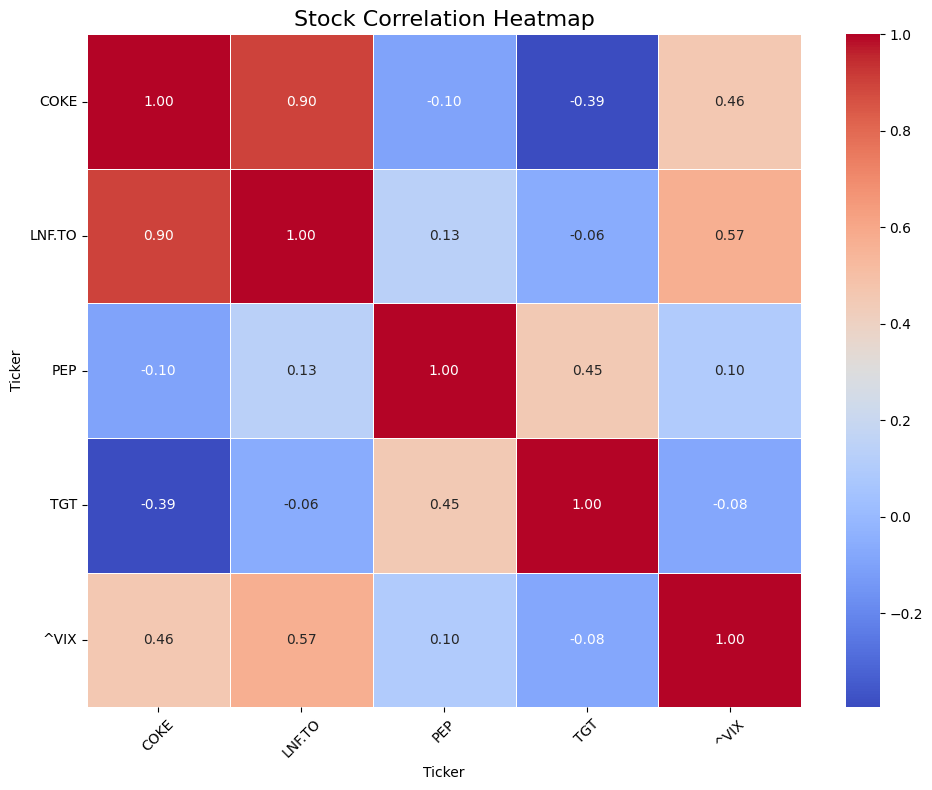

In [7]:
# Define the stock tickers you're interested in
tickers = ["^VIX","LNF.TO","TGT", "PEP", "COKE"]  # Example with 5 stocks

# If you only want two stocks, e.g., 'AAPL' and 'MSFT', you can set:
# tickers = ['AAPL', 'MSFT']

# Define the time period for the analysis
start_date = '2024-01-01'
end_date = '2025-01-28'

# Fetch the stock data
print("Fetching stock data...")
stock_data = fetch_stock_data(tickers, start_date, end_date)

# Check if data was fetched successfully
if stock_data.empty:
    print("No data fetched. Please check the ticker symbols and date range.")
    exit()

# Display the first few rows of the data
print("Sample of fetched data:")
print(stock_data.head())

# Calculate the correlation matrix
print("\nCalculating correlations...")
corr_matrix = calculate_correlations(stock_data)
print("\nCorrelation Matrix:")
print(corr_matrix)

# Plot the heatmap
print("\nPlotting heatmap...")
plot_heatmap(corr_matrix)